## Семинар 2. Культуромика на «малых данных»

На первом семинаре мы повторили **предобработку текста**: токенизацию, лемматизацию, подсчёт частотности, -- и начали работать с корпусом Посланий Федеральному собранию. Сегодняшний семинар посвящён **культуромике** —- количественному анализу культурных и социальных процессов посредством текстовых данных.

**План:**
1. Проводим мини-исследование на текстах Посланий Президента РФ к Федеральному собранию: нормализация, концепты, маркеры, n-граммы, TTR.
2. TF-IDF — выделяем ключевые слова периода.

## Подготовка данных

Ниже — код из первого семинара, который формирует корпус и таблицу лемм.

In [ ]:
import requests
import regex as re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymorphy3
from razdel import tokenize
from collections import Counter
from nltk.corpus import stopwords
from string import punctuation
import nltk
import json
from wordcloud import WordCloud

# догружаем стоп-слова, дополняем их теми же словами, которые мы предложили на первом занятии
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('russian'))
stop_words.update(['который', 'это', 'наш', 'свой', 'быть', 'мочь', 'весь', 'всё',
                   'год', 'ещё', 'аплодисменты', 'должный', 'нужно', 'необходимо',
                   'вчера', 'также', 'важный', 'стать', 'сделать', 'сегодня'])

# сохраняем морфологический парсер pymorphy3
morph = pymorphy3.MorphAnalyzer()

In [8]:
# Загрузка корпуса Посланий
urls = [
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/01_seminar/federal_assembly_address_1994.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/01_seminar/federal_assembly_address_1998.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/01_seminar/federal_assembly_address_2002.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/01_seminar/federal_assembly_address_2006.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/01_seminar/federal_assembly_address_2010.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/01_seminar/federal_assembly_address_2014.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/01_seminar/federal_assembly_address_2018.txt",
    r"https://raw.githubusercontent.com/always1ready/dh-tools/refs/heads/main/data/01_seminar/federal_assembly_address_2024.txt",
]

corpus = {}
for url in urls:
    year = re.findall(r'\d{4}', url)[0]
    response = requests.get(url)
    corpus[year] = response.text

print(f'Загружено {len(corpus)} текстов: {list(corpus.keys())}')
corpus

Загружено 8 текстов: ['1994', '1998', '2002', '2006', '2010', '2014', '2018', '2024']


{'1994': 'Послание Президента Федеральному собранию. «Об укреплении Российского государства (Основные направления внутренней и внешней политики)»\n\n\n\nавтор Б.Н. Ельцин\n\n\n\n\n\n\nПослание\n\nПрезидента Российской Федерации\n\nФедеральному Собранию Российской Федерации\n\n\n\nВВЕДЕНИЕ\n\nРоссия переживает сейчас один из важнейших этапов развития своей государственности. В конце минувшего года всенародным голосованием была принята первая в ее истории демократическая Конституция.\n\nНесмотря на острейшую политическую борьбу и духовный разлад, несмотря на огромную психическую и физическую усталость, российское общество нашло в себе силы сделать трудный, но решающий шаг на пути к обновлению и стабильности. И это многократно повышает его ценность. Долг всех нас, кто напрямую причастен к судьбе России, максимально использовать этот шанс. Два года назад мы начали болезненное, но в конечном счете необходимое и целительное реформирование экономики. С огромным трудом мы отошли от края эконом

## ЧАСТЬ 1. Лабораторная работа №1: пропроцессинг, графики (линейный, стобчатая диаграмма, облако слов), слова-маркеры, биграммы, TTR

In [14]:
# Лемматизация корпуса
def process_corpus(corpus_dict):
    full_results = {}
    for year, text in corpus_dict.items():
        tokens = [s.text.lower() for s in tokenize(text)]
        lemmas = []
        for word in tokens:
            lemma = morph.parse(word)[0].normal_form
            if lemma not in stop_words:
                lemmas.append(lemma)
        full_results[year] = Counter(lemmas)
    return full_results

final_counts = process_corpus(corpus)
final_counts

{'1994': Counter({',': 1200,
          '.': 971,
          '—': 246,
          'государство': 134,
          'россия': 134,
          'власть': 111,
          'российский': 108,
          'государственный': 105,
          ';': 89,
          'федеральный': 87,
          'право': 76,
          'реформа': 73,
          'федерация': 72,
          'система': 68,
          'орган': 64,
          'экономический': 62,
          'новый': 62,
          'закон': 61,
          'политика': 60,
          'страна': 55,
          'правовой': 55,
          'человек': 51,
          ':': 51,
          'конституция': 48,
          'политический': 48,
          'правительство': 46,
          'проблема': 45,
          'развитие': 44,
          'социальный': 44,
          'интерес': 44,
          'уровень': 44,
          'регион': 44,
          'основа': 43,
          'условие': 43,
          'гражданин': 42,
          'общество': 41,
          'национальный': 41,
          'задача': 38,
          'защита': 

Судя по выдаче, мы не удалили всю пунктуацию! 

### Задание 1
Перепишите код так, чтобы при удалении пунктуации удалялись также следующие символы: «»—„“–

In [ ]:
# ваш код

Сделаем датафрейм с частотностями лексем.

In [7]:
df = pd.DataFrame(final_counts).fillna(0).astype(int)
df.head()

,1994,1998,2002,2006,2010,2014,2018,2024
послание,11,11,4,11,7,6,35,8
президент,26,16,3,3,4,4,34,3
федеральный,87,79,23,9,9,6,35,31
собрание,23,14,10,5,2,2,32,4
укрепление,27,9,3,5,4,0,5,1


### Задание 2
Посчитайте количество слов в каждом Послании.

In [ ]:
# ваш код

1994    11234
1998    10249
2002     3661
2006     4142
2010     4481
2014     4226
2018     8219
2024     8092
dtype: int64

### Задание 3
Сделайте таблицу относительных частот лексем для каждого года (IPM):

*частотность слова в Послании / кол-во слов в Послании * 1000*

Округлите до 1 знака после запятой. Отсортируйте по 1994 году.

In [ ]:
# ваш код

### Задание 4
Выведите 10 самых частотных лемм **по всем Посланиям суммарно** (сумма нормализованных частот по строке).

Подсказка: используйте `.sum(axis=1)` и `.sort_values()`.

In [17]:
# ваш код

Относительные частоты позволяют увидеть «вес» идеи в тексте. 

### Задание 5
Выберем слова, отражающие разные направления государственной политики.

In [18]:
# Выбираем слова для анализа
target_words = [] # <-- ваш набор

# оставьте в датафрейме только строки с выбоанными словами
pass

### Задание 6
Постройте линейный график: относительная частота избраных слов в каждый из периодов

/var/folders/2s/g1vv4g7d0nn310dxqjzv9jk00000gn/T/ipykernel_3056/1588391998.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


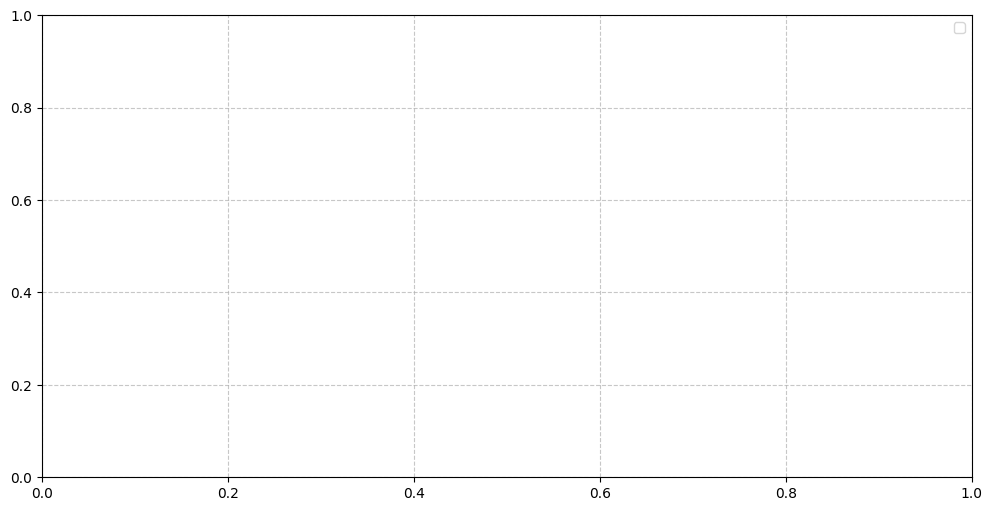

In [19]:
plt.figure(figsize=(12, 6))

# Рисуем линию для каждого слова.
#    plt.plot(x, y) — основная функция для линейных графиков.
#    ось X -- годы (колонки)
#    ось Y -- частота слова для выбранного года
#    marker='o' — точки на линии (кружки); другие варианты: 's' (квадрат), '^' (треугольник)
#    label=word — подпись для легенды
#    linewidth=2 — толщина линии в пунктах
for word in target_words:
    pass

# Оформление.
#    plt.title() — заголовок графика; fontsize — размер шрифта
pass

#plt.xlabel() 
#plt.ylabel() — подписи осей
pass

plt.legend()

#    plt.grid() — сетка для удобства чтения.
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Показываем график. В Jupyter это необязательно (рисуется автоматически),
#    но plt.show() гарантирует, что график отобразится и «закроется» —
#    следующий plt.figure() начнёт новый холст, а не дорисует на этом.
plt.show()

Слова-маркеры — это леммы, которые встречаются **только в одном году** и отсутствуют в остальных. Они часто отражают конкретные политические события или приоритеты.

In [ ]:
# Выбираем год
target = '1994'

# Создаём датафрейм без столбца со значениями выбранного года
other_years = ваш_датафрейм.columns.drop(target)

# Создаём условие-маску: суммируем значения по строкам и в качестве условия выводим только строки, равные нулю
unique_mask = ваш_датафрейм[other_years].sum(axis=1) == 0

unique = ваш_датафрейм[unique_mask][target].sort_values(ascending=False)

print(f"Слова-маркеры {target} года:")
print(unique.head(15))

### Задание 7
Напишите цикл, который найдёт слова-маркеры **для каждого года** и сохранит их в словарь `markers`.

In [ ]:
# ВАШ КОД
markers = {}

# подсказка: перебирайте колонки вашего датасета

### Задание 8

Сделайте облако слов для Послания любого года. 

In [ ]:
# ваш код

### Задание 9
Сделаем датафрейм с биграммами лемм на нашем корпусе.

In [ ]:
# Для начала нам нужен список лемм (не Counter), пересоберём
def tokenize_corpus(corpus_dict):
    results = {}
    for year, text in corpus_dict.items():
        tokens = [s.text.lower() for s in tokenize(text)]
        lemmas = [morph.parse(t)[0].normal_form for t in tokens
                  if morph.parse(t)[0].normal_form not in stop_words]
        results[year] = lemmas
    return results

texts_by_year = tokenize_corpus(corpus)

In [ ]:
# функция для создания n-грамм
def generate_ngrams(tokens, n):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-(n-1))]

`range(len(tokens)-(n-1))` — центральная часть функции. Когда мы идем по списку слов «окном» определенного размера, мы должны остановиться чуть раньше конца списка, чтобы это окно не «вывалилось» за его пределы. 

Например, если у нас 10 слов и мы ищем триграммы ($n=3$), наше последнее окно начнется на 8-м слове и захватит 8-е, 9-е и 10-е. Если мы попробуем начать окно на 9-м слове, нам просто не хватит элементов для полноценной цепочки. Формула -(n-1) как раз гарантирует, что цикл завершится ровно тогда, когда для последнего окна еще хватает слов.

`tokens[i:i+n]` — механизм среза. На каждой итерации цикла переменная i указывает на начало окна, а i+n — на его конец.

`" ".join(...)` — срезы возвращают списки слов, например `['социальная', 'сфера']`. Работать с нагромождением мелких списков неудобно, поэтому мы превращаем их в обычные строки, склеивая слова через пробел.

In [ ]:
all_years_bigrams = {}

for year in ['1994', '1998', '2002', '2006', '2010', '2014', '2018', '2024']:
    year_lemmas = texts_by_year[year] 
    
    # Генерируем биграммы
    year_bigrams = ... #ваш код
    
    # Считаем их каунтером и сохраняем в словарь all_years_bigrams
    pass

# Создаем общий DataFrame
df_ngrams = pd.DataFrame(all_years_bigrams)

# Заполняем пустоты нулями (если биграмма была в 2024, но не в 1994)
df_ngrams = df_ngrams.fillna(0).astype(int).sort_values(by='1994', ascending=False)

df_ngrams.head(15)

Выберем n-граммы-маркеры для каждого кода, как мы это делали со словами.

In [13]:
bi_markers = {}

for year in df_ngrams.columns:
    target = year
    other_years = df_ngrams.columns.drop(target)
    unique_lemmas_mask = df_ngrams[other_years].sum(axis=1) == 0
    unique = df_ngrams[unique_lemmas_mask][target].sort_values(ascending=False)
    bi_markers[year] = unique

### Оценка лексического разнообразия
Стал ли язык официальных обращений более сухим и шаблонным за последние 30 лет? Чтобы ответить на этот вопрос, мы вычислим коэффициент **TTR (Type-Token Ratio)**.

**TTR = (Число уникальных лемм / Общее число лемм) * 100%**

*Высокий TTR* говорит о богатом словарном запасе и низкой повторяемости слов. 
*Низкий TTR* указывает на обилие речевых штампов и повторов.

In [15]:
ttr_results = {}

for year in df.columns:
    # Общее количество слов (сумма по столбцу)
    total_tokens = df[year].sum()
    
    # Количество уникальных слов (где частота > 0)
    unique_types = len(df[df[year] > 0])
    
    # Считаем TTR в процентах
    ttr = (unique_types / total_tokens) * 100
    ttr_results[year] = round(ttr, 2)

### Задание 10. Постройте столбчатую диаграмму, которая будет отражать лесическое разнообразие Посланий

In [ ]:
# Подготовка данных: словарь -> два списка (для осей X и Y)
years = list(ttr_results.keys())    # ['1994', '1998', ...]
values = list(ttr_results.values())  # [34.2, 28.5, ...]

# Создаём холст
plt.figure(figsize=(10, 5))

# Рисуем столбцы
# plt.bar(x, y) — рисует столбцы.
#   color  — цвет заливки столбцов
#   edgecolor — цвет обводки столбцов
pass

# Заголовок и подпись оси Y
plt.title('Лексическое разнообразие Посланий (TTR %)', fontsize=14)
plt.ylabel('Процент уникальных слов', fontsize=12)

plt.show()

## ЧАСТЬ 2. TF-IDF — ключевые слова периода

### Зачем нужен TF-IDF, если у нас есть частоты?

Cамые частотные слова нередко оказываются общими для всех текстов: «государство», «развитие», «страна». Их абсолютная или относительная частота будут довольно высокими на нашем материале, но это не помогает определить ключевые понятия периода. Если в случае больших разнородных корпусов хватит даже абсолютной частотности, то в корпусе с однородными текстами найти ключевые слова труднее.

**TF-IDF (Term Frequency — Inverse Document Frequency)** решает эту проблему. Метрика повышает вес слов, которые часты в конкретном тексте, но редки в коллекции в целом. В культуромическом исследовании мы как раз пытаемся найти слова, характерные для эпохи. 

Разберём метрику по шагам.

### Шаг 1. Term Frequency (TF) — частота слова в документе

TF отвечает на вопрос: **насколько часто слово встречается в данном тексте?**

$$\text{TF}(t, d) = \frac{\text{Число вхождений слова } t \text{ в документ } d}{\text{Общее число слов в документе } d}$$

По сути, это та самая относительная частота, которую мы уже считали в разделе 1.1, только нормированная на единицу, а не на тысячу.

Посчитаем TF для слова «демократия» в Посланиях 1994 и 2024 года.

In [16]:
# TF для слова «демократия»
word = 'демократия'

for year in ['1994', '2024']:
    # Количество вхождений слова в данный год
    count = df.loc[word, year] if word in df.index else 0
    
    # Общее число слов (лемм) в данный год
    total = df[year].sum()
    
    # TF = доля слова в тексте
    tf = count / total
    
    print(f'{year}: слово «{word}» встретилось {count} раз из {total} слов\n')
    print(f'       TF = {count}/{total} = {tf:.6f}')
    print()

1994: слово «демократия» встретилось 11 раз из 11234 слов

       TF = 11/11234 = 0.000979

2024: слово «демократия» встретилось 1 раз из 8092 слов

       TF = 1/8092 = 0.000124



### Шаг 2. Inverse Document Frequency (IDF) — обратная документная частота

IDF отвечает на вопрос: **насколько слово уникально для коллекции?**

$$\text{IDF}(t) = \log\frac{N}{\text{DF}(t)}$$

где $N$ — общее число документов в коллекции, а $\text{DF}(t)$ — в скольких документах встречается слово $t$.

Идея: если слово встречается **во всех** документах (например, «государство»), то $\text{DF} = N$, и $\text{IDF} = \log(1) = 0$. Такое слово получит нулевой вес — оно не помогает различать тексты.

Если слово встречается **только в одном** документе, то $\text{IDF} = \log(N)$ — максимальный вес.

Функция логарифма здесь нужна, чтобы сгладить различия: без неё слово из одного документа получило бы вес в 8 раз больше, чем слово из всех документов. Логарифм делает шкалу более плавной.

In [22]:
import math

N = len(df.columns)  # число документов (Посланий)
print(f'Всего документов: {N}')
print()

for word in ['демократия', 'государство', 'крым']:
    if word not in df.index:
        print(f'«{word}»: не найдено в корпусе')
        continue
    
    # DF = в скольких годах слово встречается хотя бы раз
    document_freq = (df.loc[word] > 0).sum()
    
    # IDF = log(N / DF)
    idf = math.log(N / document_freq)
    
    print(f'«{word}»: встречается в {document_freq} из {N} документов\n')
    print(f'         IDF = log( {N}/{document_freq} ) = {idf:.4f}')
    print()

Всего документов: 8

«демократия»: встречается в 7 из 8 документов

         IDF = log( 8/7 ) = 0.1335

«государство»: встречается в 8 из 8 документов

         IDF = log( 8/8 ) = 0.0000

«крым»: встречается в 3 из 8 документов

         IDF = log( 8/3 ) = 0.9808



### Шаг 3. TF-IDF = TF × IDF

Теперь перемножаем. Слово получает высокий вес, если оно одновременно:
- **часто** в данном документе (высокий TF)
- **редко** в коллекции в целом (высокий IDF)

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Посчитаем TF-IDF для нескольких слов и сравним 1994 и 2024.

In [25]:
import math
# Считаем TF-IDF вручную для нескольких слов
test_words = ['демократия', 'свобода', 'безопасность', 'крым', 'государство']

for word in test_words:
    if word not in df.index:
        continue
    
    document_freq = (df.loc[word] > 0).sum()
    idf = math.log(N / document_freq)
    
    for year in ['1994', '2024']:
        count = df.loc[word, year]
        total = df[year].sum()
        tf = count / total
        tfidf = tf * idf
        
        print(f"{year}: {word}, {tfidf}")
    print()

1994: демократия, 0.00013074998387660214
2024: демократия, 1.6501655045047277e-05

1994: свобода, 0.0
2024: свобода, 0.0

1994: безопасность, 0.0
2024: безопасность, 0.0

1994: крым, 0.0
2024: крым, 0.00012120974456398

1994: государство, 0.0
2024: государство, 0.0



Обратите внимание: у слова «государство» TF-IDF = 0, потому что оно встречается **во всех** Посланиях (IDF = 0). А слово «крым», которое появляется в 3-х Посланиях, получает высокий вес — именно оно характерно для этого периода.

Это принципиальное отличие от простой частоты: TF-IDF автоматически отсеивает «общие» слова и выделяет «особенные».

Реализуем подсчёт TF-IDF для **всех слов** корпуса. Для каждого года выведите топ-10 слов с наибольшим TF-IDF.
Результат удобно хранить в словаре `{год: {слово: tfidf_score}}`, а потом превратить в DataFrame.

In [32]:
# 1. Вычисляем IDF для каждого слова один раз
idf_dict = {}
for word in df.index:
    # количество лет, в которых слово встречается (частота > 0)
    docs_with_word = (df.loc[word] > 0).sum()
    idf = math.log(N / docs_with_word) if docs_with_word > 0 else 0
    idf_dict[word] = idf

# 2. Словарь для хранения результатов: {год: {слово: tfidf}}
tfidf_by_year = {}

# 3. Для каждого года считаем TF и TF-IDF
for year in df.columns:
    total_words_in_year = df[year].sum()  # общее количество словоупотреблений в году
    year_tfidf = {}
    
    for word in df.index:
        count = df.loc[word, year]
        tf = count / total_words_in_year if total_words_in_year > 0 else 0
        tfidf = tf * idf_dict[word]
        year_tfidf[word] = tfidf
    
    # Сохраняем словарь для года
    tfidf_by_year[year] = year_tfidf

tfidf_df = pd.DataFrame(tfidf_by_year)
tfidf_df

,1994,1998,2002,2006,2010,2014,2018,2024
послание,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
президент,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
федеральный,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
собрание,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
укрепление,0.000321,0.000117,0.000109,0.000161,0.000119,0.0,0.000081,0.000017
...,...,...,...,...,...,...,...,...
отчизна,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000257
поклон,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000257
гимн,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000257
гостиный,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000257


In [36]:
for year in tfidf_df.columns:
    top5 = tfidf_df[year].sort_values(ascending=False).head(7)
    print(f"Год {year}:")
    for word, score in top5.items():
        if word.isalpha():
            print(f"  {word}: {score:.3f}")
    print()

Год 1994:
  конституция: 0.004
  реформа: 0.002
  противоречие: 0.002
  конституционный: 0.002
  религиозный: 0.002

Год 1998:
  неплатёж: 0.003
  исполнительный: 0.002
  подъём: 0.002
  трансферт: 0.001
  реформа: 0.001

Год 2002:
  перепись: 0.003
  вто: 0.003
  зарабатывать: 0.002
  исполнительный: 0.001
  монополия: 0.001
  разграничение: 0.001
  уважаемый: 0.001

Год 2006:
  женщина: 0.003
  родить: 0.002
  ядерный: 0.002
  взимать: 0.002
  пособие: 0.001
  вышеназванный: 0.001

Год 2010:
  четвёртый: 0.002
  ребёнок: 0.002
  детский: 0.002
  поручать: 0.002
  седьмой: 0.001
  немаловажный: 0.001
  полиция: 0.001

Год 2014:
  крым: 0.002
  украина: 0.002
  севастополь: 0.002
  репутация: 0.002
  моногород: 0.001

Год 2018:
  скорость: 0.003
  оглашение: 0.003
  ядерный: 0.002
  дальность: 0.002
  тонна: 0.002
  сервис: 0.002
  цифровой: 0.002

Год 2024:
  тыс: 0.005
  млрд: 0.005
  млн: 0.004
  дополнительно: 0.002
  шесть: 0.002
  донбасс: 0.002



### Готовое решение: sklearn

Изучаемые нами метрики уже реализованы в специальных библиотеках. Мы пишем код самостоятельно, чтобы понять, как они работают, но на практике удобнее использовать готовые решения. `TfidfVectorizer` из библиотеки `sklearn` делает то же самое (с некоторыми дополнительными нормализациями), но быстрее и надёжнее.

Обратите внимание: `TfidfVectorizer` принимает на вход **строки**, а не списки слов. Поэтому нам нужно склеить леммы обратно в строки.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def lemmatize(corpus_dict):
    lemmatized = {}
    for year, text in corpus_dict.items():
        tokens = [s.text.lower() for s in tokenize(text)]
        lemmas = []
        for word in tokens:
            lemma = morph.parse(word)[0].normal_form
            if lemma not in stop_words:
                lemmas.append(lemma)
        lemmatized[year] = " ".join(lemmas)
    return lemmatized

corpus_lemmatized = lemmatize(corpus)

years_list = corpus_lemmatized.keys()
texts_list = corpus_lemmatized.values()

# Считаем TF-IDF
vectorizer = TfidfVectorizer(stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(texts_list)

print(f'\nРазмер матрицы: {tfidf_matrix.shape}')
print(f'(строки = годы, столбцы = уникальные слова)')
tfidf_matrix


Размер матрицы: (8, 6865)
(строки = годы, столбцы = уникальные слова)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 17464 stored elements and shape (8, 6865)>

In [ ]:
# так можно извлечь слова, по которым мы векторизовали
feature_names = vectorizer.get_feature_names_out()
feature_names

array(['00', '10', '100', ..., 'ясный', 'ящик', 'ёмкий'],
      shape=(6865,), dtype=object)

In [53]:
# Извлекаем топ-10 слов с наивысшим TF-IDF для каждого года
for i, year in enumerate(years_list):
    # Берём строку матрицы для данного года и превращаем в обычный массив
    row = tfidf_matrix[i].toarray().flatten()

    # Сортируем индексы по убыванию значения TF-IDF, берём первые 10
    top_indices = row.argsort()[-10:][::-1]

    # Извлекаем слова и их веса
    top_words = [(feature_names[j], round(row[j], 3)) for j in top_indices]
    
    print(f'\n{year}:')
    for word, score in top_words:
        print(f'  {word}: {score}')


1994:
  государство: 0.244
  россия: 0.244
  власть: 0.202
  российский: 0.196
  государственный: 0.191
  реформа: 0.166
  федеральный: 0.158
  конституция: 0.158
  право: 0.138
  федерация: 0.131

1998:
  государственный: 0.233
  власть: 0.199
  система: 0.179
  федеральный: 0.171
  россия: 0.168
  экономический: 0.151
  орган: 0.151
  страна: 0.138
  реформа: 0.132
  1998: 0.13

2002:
  страна: 0.221
  россия: 0.198
  государственный: 0.176
  экономический: 0.159
  власть: 0.147
  гражданин: 0.142
  система: 0.136
  федеральный: 0.13
  российский: 0.125
  работа: 0.125

2006:
  страна: 0.189
  россия: 0.184
  развитие: 0.15
  ребёнок: 0.149
  проблема: 0.139
  вопрос: 0.128
  новый: 0.128
  женщина: 0.121
  сила: 0.117
  условие: 0.111

2010:
  ребёнок: 0.358
  новый: 0.185
  детский: 0.127
  модернизация: 0.125
  система: 0.125
  жизнь: 0.115
  россия: 0.115
  человек: 0.11
  страна: 0.11
  государственный: 0.105

2014:
  россия: 0.323
  человек: 0.153
  страна: 0.137
  развитие: 0

### На подумать
Сравните слова-маркеры из раздела 1.3 со словами с высоким TF-IDF. Что совпадает? Какой метод, на ваш взгляд, лучше выделяет «дух эпохи»? 